# Notebook 3 — Reproducible comparative evaluation of multimodal (VLM) architectures

**CV claim this notebook backs up**
> *Development of reproducible pipelines for the comparative evaluation of multimodal architectures.*

**Design principle:** one pipeline, one benchmark sample, one decoding budget, one set of metrics, one independent judge — only the **architecture** changes.

| Architecture | Vision side → language side | Family |
|---|---|---|
| **BLIP-base** | ViT → BERT-style decoder (cross-attention) | VLP encoder–decoder |
| **BLIP-large** | larger ViT-L → BERT-style decoder | same family, scale ablation |
| **ViT-GPT2** | ViT → GPT-2 (cross-attention) | plain encoder–decoder |
| **GIT-base-COCO** | CLIP-style ViT → single Transformer decoder | generative image-to-text |
| **Qwen2-VL-2B-Instruct** | native-resolution ViT → Qwen2 LLM (instruction-tuned, prompted) | modern LLM-based VLM |
| *(optional)* **BLIP-2 OPT-2.7B** | ViT → Q-Former → OPT LLM | frozen-LLM bridge (`ENABLE_BLIP2=True`) |

**Same for every architecture**
* Flickr30k images + 5 human captions (identical sample), identical text normalisation
* Identical decoding budget: `max_new_tokens=30`, **greedy** for the deterministic baseline (no per-model beam search), identical nucleus sampling (T=1.0, top-p 0.9, top-k off) for k rollouts
* Classical: BLEU-4, ROUGE-1/L, METEOR, CIDEr · Reference-free: CLIPScore with an **independent CLIP-L/14 judge** (plus B/32 as second opinion)
* RL-based: Monte-Carlo expected return J(π) over k rollouts, self-critical (SCST) advantage, reward std across rollouts, best-of-k headroom
* Hybrid α·classical + β·reward with **pooled** min-max normalisation across *all* architectures (normalising inside each model would destroy comparability) and an **α-sensitivity ranking-stability** analysis
* Paired bootstrap significance between architectures; latency, peak VRAM, parameter count logged

**Honesty notes**
* Evaluation is on Flickr30k while several models were tuned on COCO captions (BLIP, GIT, ViT-GPT2) → an **out-of-domain** setting for them; state that if asked.
* Qwen2-VL is an instruction-following model: its captions depend on the prompt and tend to be longer/more detailed than COCO-style references, which penalises n-gram metrics. The report shows caption length so this is visible, not hidden.
* An architecture that fails to load/run is recorded as failed in the output — the notebook never substitutes fake numbers.
* Default 200 images × (1 greedy + 4 sampled) per architecture. RL = evaluation-time rewards/returns/advantages; no policy is trained.


In [1]:
# ============================================================================
# 0. ENVIRONMENT  (run the installs once, in a terminal, BEFORE opening the notebook)
# ----------------------------------------------------------------------------
# RTX 50-series laptops (Blackwell, compute capability sm_120) need a PyTorch
# build compiled against CUDA 12.8 or newer:
#     pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
#     pip install -r requirements.txt
# ============================================================================
import os, sys, json, time, random, platform, re, math, itertools, warnings, gc
from importlib import metadata
warnings.filterwarnings("ignore")

os.environ["HF_HUB_DISABLE_XET"] = "1"        # avoids the stalling "reconstructing file" path
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120" # more patience on slow connections

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

# ---- GPU sanity check (fails loudly instead of silently running on CPU) ----
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Install the cu128 PyTorch build (see the top of this cell) "
                       "and make sure the NVIDIA driver is up to date.")
DEVICE = "cuda"
_cap = torch.cuda.get_device_capability(0)
_arch = f"sm_{_cap[0]}{_cap[1]}"
if _arch not in torch.cuda.get_arch_list():
    raise RuntimeError(f"This PyTorch build ({torch.__version__}) has no kernels for {_arch} "
                       f"(GPU: {torch.cuda.get_device_name(0)}). Install the cu128 build: "
                       "pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128")
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f"GPU     : {torch.cuda.get_device_name(0)}  ({_arch}, "
      f"{torch.cuda.get_device_properties(0).total_memory/2**30:.1f} GiB)")
print(f"PyTorch : {torch.__version__} | CUDA {torch.version.cuda} | dtype for generation: {DTYPE}")


GPU     : NVIDIA GeForce RTX 5070 Laptop GPU  (sm_120, 8.0 GiB)
PyTorch : 2.11.0+cu128 | CUDA 12.8 | dtype for generation: torch.bfloat16


In [2]:
# ============================================================================
# Shared utilities: statistics, reproducibility manifest, tables
# ============================================================================
def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def bootstrap_ci(x, n_boot=2000, alpha=0.05, seed=SEED):
    """Percentile bootstrap CI of the mean. Returns (mean, lo, hi)."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    means = x[idx].mean(axis=1)
    return float(x.mean()), float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2))

def paired_bootstrap(a, b, n_boot=2000, seed=SEED):
    """Paired bootstrap of mean(a-b) over items. Returns (mean_diff, lo, hi, P(diff<=0))."""
    d = np.asarray(a, float) - np.asarray(b, float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(n_boot, len(d)))
    m = d[idx].mean(axis=1)
    return float(d.mean()), float(np.quantile(m, 0.025)), float(np.quantile(m, 0.975)), float((m <= 0).mean())

def ci_str(t, nd=3):
    m, lo, hi = t
    return f"{m:.{nd}f} [{lo:.{nd}f}, {hi:.{nd}f}]"

def minmax(x, lo=None, hi=None):
    x = np.asarray(x, dtype=float)
    lo = x.min() if lo is None else lo
    hi = x.max() if hi is None else hi
    return (x - lo) / (hi - lo + 1e-12)

def df_to_md(df, nd=3):
    cols = list(df.columns)
    def f(v):
        return f"{v:.{nd}f}" if isinstance(v, (float, np.floating)) else str(v)
    lines = ["| " + " | ".join(map(str, cols)) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, r in df.iterrows():
        lines.append("| " + " | ".join(f(r[c]) for c in cols) + " |")
    return "\n".join(lines)

def write_manifest(path, config, extra=None):
    """Everything needed to reproduce / audit a run."""
    pk = ["torch", "transformers", "datasets", "accelerate", "sacrebleu", "rouge-score", "nltk",
          "bert-score", "pycocoevalcap", "scipy", "numpy", "pandas", "pillow"]
    ver = {}
    for p in pk:
        try: ver[p] = metadata.version(p)
        except Exception: ver[p] = None
    man = dict(
        timestamp=time.strftime("%Y-%m-%d %H:%M:%S"),
        python=sys.version.split()[0], platform=platform.platform(),
        gpu=torch.cuda.get_device_name(0), cuda=torch.version.cuda, torch=torch.__version__,
        versions=ver, seed=SEED, config=config, **(extra or {}),
    )
    with open(path, "w") as fh:
        json.dump(man, fh, indent=2, default=str)
    return man


In [3]:
OUT_DIR = "outputs_comparative"; os.makedirs(OUT_DIR, exist_ok=True)
ENABLE_BLIP2 = False          # +7.7 GB of weights in bf16; fits a 12 GB GPU but is slow to download

CFG = dict(
    n_images=200, k_samples=4, temperature=1.0, top_p=0.9, max_new_tokens=30, gen_batch=8,
    clip_judge="openai/clip-vit-large-patch14",        # primary independent judge / RL reward
    clip_second="openai/clip-vit-base-patch32",        # second opinion
    alpha=0.4, beta=0.6,
    qwen_prompt="Write a one-sentence caption for this image.",
    qwen_max_pixels=448 * 448,
)
ARCH_IDS = {
    "BLIP-base":  "Salesforce/blip-image-captioning-base",
    "BLIP-large": "Salesforce/blip-image-captioning-large",
    "ViT-GPT2":   "nlpconnect/vit-gpt2-image-captioning",
    "GIT-base":   "microsoft/git-base-coco",
    "Qwen2-VL-2B": "Qwen/Qwen2-VL-2B-Instruct",
}
if ENABLE_BLIP2: ARCH_IDS["BLIP2-OPT-2.7B"] = "Salesforce/blip2-opt-2.7b"
print(json.dumps(CFG, indent=2)); print(ARCH_IDS)

{
  "n_images": 200,
  "k_samples": 4,
  "temperature": 1.0,
  "top_p": 0.9,
  "max_new_tokens": 30,
  "gen_batch": 8,
  "clip_judge": "openai/clip-vit-large-patch14",
  "clip_second": "openai/clip-vit-base-patch32",
  "alpha": 0.4,
  "beta": 0.6,
  "qwen_prompt": "Write a one-sentence caption for this image.",
  "qwen_max_pixels": 200704
}
{'BLIP-base': 'Salesforce/blip-image-captioning-base', 'BLIP-large': 'Salesforce/blip-image-captioning-large', 'ViT-GPT2': 'nlpconnect/vit-gpt2-image-captioning', 'GIT-base': 'microsoft/git-base-coco', 'Qwen2-VL-2B': 'Qwen/Qwen2-VL-2B-Instruct'}


In [4]:
# ============================================================================
# Classical captioning metrics (identical code for every model that is scored)
# ============================================================================
import nltk
for _pkg in ["wordnet", "omw-1.4"]:
    nltk.download(_pkg, quiet=True)
import sacrebleu
from rouge_score import rouge_scorer
from nltk.translate.meteor_score import meteor_score
from pycocoevalcap.cider.cider import Cider

_rouge = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

def norm_cap(s):
    return " ".join(re.findall(r"[a-z0-9']+", s.lower()))

def caption_metrics(preds, refs):
    """preds: list[str]; refs: list[list[str]] (multi-reference).
    Returns (summary dict, per-sample DataFrame). Text is lower-cased / punctuation-stripped
    identically for candidates and references."""
    P = [norm_cap(p) for p in preds]
    R = [[norm_cap(r) for r in rs] for rs in refs]
    m = min(len(r) for r in R)
    bleu = sacrebleu.corpus_bleu(P, [[r[i] for r in R] for i in range(m)]).score / 100.0
    r1, rL, met = [], [], []
    for p, rs in zip(P, R):
        r1.append(max(_rouge.score(r, p)["rouge1"].fmeasure for r in rs))
        rL.append(max(_rouge.score(r, p)["rougeL"].fmeasure for r in rs))
        met.append(meteor_score([r.split() for r in rs], p.split()))
    cider, cider_i = Cider().compute_score({i: R[i] for i in range(len(P))}, {i: [P[i]] for i in range(len(P))})
    per = pd.DataFrame({"rouge1": r1, "rougeL": rL, "meteor": met, "cider": np.asarray(cider_i)})
    summ = dict(bleu4=bleu, rouge1=float(np.mean(r1)), rougeL=float(np.mean(rL)),
                meteor=float(np.mean(met)), cider=float(cider))
    return summ, per


In [5]:
# ============================================================================
# CLIP tooling: reward model (image<->text alignment) + cross-modal retrieval
# ============================================================================
from transformers import CLIPModel, CLIPProcessor

def _feat(o):
    return o.pooler_output if hasattr(o, "pooler_output") else o

class ClipScorer:
    def __init__(self, model_id):
        self.model_id = model_id
        self.proc = CLIPProcessor.from_pretrained(model_id)
        self.model = CLIPModel.from_pretrained(model_id).to(DEVICE, torch.float16).eval()

    @torch.no_grad()
    def embed_images(self, images, bs=64):
        out = []
        for i in range(0, len(images), bs):
            pv = self.proc(images=images[i:i + bs], return_tensors="pt")["pixel_values"].to(DEVICE, torch.float16)
            e = _feat(self.model.get_image_features(pixel_values=pv)).float()
            out.append(torch.nn.functional.normalize(e, dim=-1).cpu())
        return torch.cat(out)

    @torch.no_grad()
    def embed_texts(self, texts, bs=256):
        out = []
        for i in range(0, len(texts), bs):
            t = self.proc(text=texts[i:i + bs], return_tensors="pt", padding=True, truncation=True, max_length=77).to(DEVICE)
            e = _feat(self.model.get_text_features(input_ids=t["input_ids"], attention_mask=t["attention_mask"])).float()
            out.append(torch.nn.functional.normalize(e, dim=-1).cpu())
        return torch.cat(out)

    def reward(self, img_emb, texts):
        """Per-item cosine(image, text) - the RL reward. CLIPScore (Hessel et al.) = 2.5 * max(cos, 0)."""
        return (img_emb * self.embed_texts(texts)).sum(-1).numpy()

    def close(self):
        del self.model; free_gpu()

def retrieval_metrics(img_emb, txt_emb, txt2img):
    """Flickr-style protocol: N images, several captions each.
    i2t: an image counts as retrieved if ANY of its GT captions is within top-K. t2i: each caption -> its image."""
    sim = (img_emb @ txt_emb.T).numpy()                    # [N, T]
    txt2img = np.asarray(txt2img)
    N = sim.shape[0]
    order = np.argsort(-sim, axis=1)
    i2t = np.array([np.where(txt2img[order[i]] == i)[0].min() for i in range(N)])
    order_t = np.argsort(-sim.T, axis=1)
    t2i = np.array([np.where(order_t[j] == txt2img[j])[0][0] for j in range(sim.shape[1])])
    out = {}
    for name, ranks in (("i2t", i2t), ("t2i", t2i)):
        for k in (1, 5, 10):
            out[f"{name}_R@{k}"] = 100.0 * float((ranks < k).mean())
        out[f"{name}_medR"] = float(np.median(ranks) + 1)
    out["rsum"] = sum(out[f"{n}_R@{k}"] for n in ("i2t", "t2i") for k in (1, 5, 10))
    return out


In [6]:
# ============================================================================
# Data: Flickr30k (real images + 5 human captions each), streamed from the HF Hub
# ============================================================================
from datasets import load_dataset

FLICKR_CANDIDATES = [("lmms-lab/flickr30k", "test"), ("nlphuji/flickr30k", "test")]

def load_flickr(n):
    last = None
    for ds_id, split in FLICKR_CANDIDATES:
        try:
            print(f"Streaming {ds_id}[{split}] ({n} images)...")
            try:
                ds = load_dataset(ds_id, split=split, streaming=True)
            except Exception:
                ds = load_dataset(ds_id, split=split, streaming=True, trust_remote_code=True)
            items = list(itertools.islice(ds, n))
            images, refs = [], []
            for it in items:
                images.append(it["image"].convert("RGB"))
                c = it["caption"]
                refs.append([c] if isinstance(c, str) else list(c))
            m = min(len(r) for r in refs)
            assert m >= 1
            print(f"OK  {len(images)} images, >= {m} human captions each  (source: {ds_id})")
            return images, refs, ds_id
        except Exception as e:
            last = e
            print(f"  could not use {ds_id}: {type(e).__name__}: {str(e)[:150]}")
    raise RuntimeError(f"No Flickr30k source worked. Last error: {last}")


In [7]:
images, refs, FLICKR_SRC = load_flickr(CFG["n_images"])   # SAME images for every architecture

Streaming lmms-lab/flickr30k[test] (200 images)...


OK  200 images, >= 5 human captions each  (source: lmms-lab/flickr30k)


In [8]:
# ============================================================================
# 2. One adapter per architecture. Contract:  gen(images, sample: bool) -> list[str]
#    Decoding kwargs come from ONE function so that no model gets special treatment.
# ============================================================================
from transformers import (BlipProcessor, BlipForConditionalGeneration, VisionEncoderDecoderModel, ViTImageProcessor,
                          AutoTokenizer, AutoProcessor, AutoModelForCausalLM, Blip2Processor, Blip2ForConditionalGeneration)

def gen_kwargs(sample):
    if sample:
        return dict(max_new_tokens=CFG["max_new_tokens"], do_sample=True, temperature=CFG["temperature"],
                    top_p=CFG["top_p"], top_k=0, num_beams=1)
    return dict(max_new_tokens=CFG["max_new_tokens"], do_sample=False, temperature=None, top_p=None, top_k=None, num_beams=1)

def _from(cls, mid, **kw):
    try: m = cls.from_pretrained(mid, dtype=DTYPE, **kw)
    except TypeError: m = cls.from_pretrained(mid, torch_dtype=DTYPE, **kw)
    return m.to(DEVICE).eval()

class Arch:
    def __init__(self, parts, gen, model):
        self.parts, self.gen = parts, gen
        self.n_params = sum(p.numel() for p in model.parameters())
        self.commit = getattr(model.config, "_commit_hash", None)
    def close(self):
        self.parts.clear(); free_gpu()

def batches(images):
    for i in range(0, len(images), CFG["gen_batch"]):
        yield images[i:i + CFG["gen_batch"]]

def load_blip(mid):
    parts = dict(proc=BlipProcessor.from_pretrained(mid), model=_from(BlipForConditionalGeneration, mid))
    def gen(images, sample=False):
        out = []
        for b in batches(images):
            pv = parts["proc"](images=b, return_tensors="pt")["pixel_values"].to(DEVICE, DTYPE)
            with torch.no_grad(): ids = parts["model"].generate(pixel_values=pv, **gen_kwargs(sample))
            out += [c.strip() for c in parts["proc"].batch_decode(ids, skip_special_tokens=True)]
        return out
    return Arch(parts, gen, parts["model"])

def load_vit_gpt2(mid):
    tok = AutoTokenizer.from_pretrained(mid); tok.pad_token = tok.pad_token or tok.eos_token
    parts = dict(fe=ViTImageProcessor.from_pretrained(mid), tok=tok, model=_from(VisionEncoderDecoderModel, mid))
    def gen(images, sample=False):
        out = []
        for b in batches(images):
            pv = parts["fe"](images=b, return_tensors="pt")["pixel_values"].to(DEVICE, DTYPE)
            with torch.no_grad(): ids = parts["model"].generate(pixel_values=pv, pad_token_id=tok.pad_token_id, **gen_kwargs(sample))
            out += [c.strip() for c in parts["tok"].batch_decode(ids, skip_special_tokens=True)]
        return out
    return Arch(parts, gen, parts["model"])

def load_git(mid):
    parts = dict(proc=AutoProcessor.from_pretrained(mid), model=_from(AutoModelForCausalLM, mid))
    def gen(images, sample=False):
        out = []
        for b in batches(images):
            pv = parts["proc"](images=b, return_tensors="pt")["pixel_values"].to(DEVICE, DTYPE)
            with torch.no_grad(): ids = parts["model"].generate(pixel_values=pv, **gen_kwargs(sample))
            out += [c.strip() for c in parts["proc"].batch_decode(ids, skip_special_tokens=True)]
        return out
    return Arch(parts, gen, parts["model"])

def load_qwen2vl(mid):
    from transformers import Qwen2VLForConditionalGeneration
    proc = AutoProcessor.from_pretrained(mid, max_pixels=CFG["qwen_max_pixels"])
    proc.tokenizer.padding_side = "left"
    parts = dict(proc=proc, model=_from(Qwen2VLForConditionalGeneration, mid))
    msgs = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": CFG["qwen_prompt"]}]}]
    text = proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    def gen(images, sample=False):
        out = []
        for b in batches(images):
            enc = parts["proc"](text=[text] * len(b), images=b, padding=True, return_tensors="pt").to(DEVICE)
            with torch.no_grad(): ids = parts["model"].generate(**enc, **gen_kwargs(sample))
            out += [c.strip() for c in parts["proc"].batch_decode(ids[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)]
        return out
    return Arch(parts, gen, parts["model"])

def load_blip2(mid):
    parts = dict(proc=Blip2Processor.from_pretrained(mid), model=_from(Blip2ForConditionalGeneration, mid))
    def gen(images, sample=False):
        out = []
        for b in batches(images):
            enc = parts["proc"](images=b, return_tensors="pt")
            with torch.no_grad(): ids = parts["model"].generate(pixel_values=enc["pixel_values"].to(DEVICE, DTYPE), **gen_kwargs(sample))
            out += [c.strip() for c in parts["proc"].batch_decode(ids, skip_special_tokens=True)]
        return out
    return Arch(parts, gen, parts["model"])

LOADERS = {"BLIP-base": load_blip, "BLIP-large": load_blip, "ViT-GPT2": load_vit_gpt2, "GIT-base": load_git,
           "Qwen2-VL-2B": load_qwen2vl, "BLIP2-OPT-2.7B": load_blip2}

In [9]:
# ============================================================================
# 3. Run every architecture through the IDENTICAL pipeline (generation only here; scoring is
#    done afterwards on the pooled results so that normalisation is shared).
# ============================================================================
K = CFG["k_samples"]; N = len(images)
OUT = {}      # name -> dict(greedy, samples, meta)   |   FAILED[name] -> error string
FAILED = {}
for name, mid in ARCH_IDS.items():
    cache = f"{OUT_DIR}/gen_{name}.json"
    if os.path.exists(cache):
        OUT[name] = json.load(open(cache)); print(f"[{name}] loaded cached generations"); continue
    print(f"\n{'='*78}\n{name}: {mid}\n{'='*78}")
    arch = None
    try:
        set_seed(); torch.cuda.reset_peak_memory_stats()
        arch = LOADERS[name](mid)
        arch.gen(images[:CFG["gen_batch"]])                               # warm-up (CUDA kernels / autotune), not timed
        torch.cuda.synchronize(); t0 = time.time()
        greedy = arch.gen(images); torch.cuda.synchronize(); dt = time.time() - t0
        set_seed()
        samples = [arch.gen(images, sample=True) for _ in range(K)]          # [K][N]
        samples = [list(x) for x in zip(*samples)]                           # [N][K]
        OUT[name] = dict(model_id=mid, commit=arch.commit, params_m=round(arch.n_params / 1e6, 1),
                         sec_per_image=round(dt / N, 4), peak_vram_gib=round(torch.cuda.max_memory_allocated() / 2**30, 2),
                         greedy=greedy, samples=samples)
        json.dump(OUT[name], open(cache, "w"))
        print(f"[{name}] {OUT[name]['params_m']}M params | {OUT[name]['sec_per_image']} s/img | peak {OUT[name]['peak_vram_gib']} GiB")
        print(f"   e.g. {greedy[0]!r}")
    except Exception as e:
        FAILED[name] = f"{type(e).__name__}: {str(e)[:300]}"
        print(f"[{name}] FAILED -> {FAILED[name]}   (recorded, continuing)")
    finally:
        if arch is not None: arch.close()
        free_gpu()
if not OUT: raise RuntimeError("No architecture ran successfully - see errors above.")
names = list(OUT)

[BLIP-base] loaded cached generations
[BLIP-large] loaded cached generations

ViT-GPT2: nlpconnect/vit-gpt2-image-captioning


pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

[Qwen2-VL-2B] 2209.0M params | 0.3432 s/img | peak 4.49 GiB
   e.g. 'Two men in a garden with one wearing a blue shirt.'


In [10]:
# ============================================================================
# 4. Score everything with the SAME code: classical + CLIP judge/reward + RL quantities
# ============================================================================
judge = ClipScorer(CFG["clip_judge"]); second = ClipScorer(CFG["clip_second"])
Ej, Es = judge.embed_images(images), second.embed_images(images)

def sample_rewards(scorer, E, samples):
    flat = [s for ss in samples for s in ss]
    return scorer.reward(E.repeat_interleave(K, dim=0), flat).reshape(N, K)

S = {}      # per-architecture scored results
for n in names:
    o = OUT[n]
    summ, per = caption_metrics(o["greedy"], refs)
    rg = judge.reward(Ej, o["greedy"]);  rs = sample_rewards(judge, Ej, o["samples"])
    rg2 = second.reward(Es, o["greedy"])
    S[n] = dict(summ=summ, per=per, rg=rg, rs=rs, rg2=rg2,
                J=rs.mean(1), adv=rs.mean(1) - rg, adv_traj=rs - rg[:, None], rstd=rs.std(1),
                length=np.mean([len(c.split()) for c in o["greedy"]]),
                distinct=len(set(o["greedy"])) / N,
                bok=np.concatenate([rg[:, None], rs], 1).max(1))
    print(f"[{n}] scored")
judge.close(); second.close()

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[BLIP-base] scored
[BLIP-large] scored
[ViT-GPT2] scored
[GIT-base] scored
[Qwen2-VL-2B] scored


In [11]:
# ============================================================================
# 5. HYBRID score with POOLED normalisation + alpha-sensitivity / ranking stability
# ============================================================================
pool = np.concatenate([S[n]["rg"] for n in names]); lo, hi = pool.min(), pool.max()
for n in names:
    S[n]["classical"] = ((S[n]["per"]["rougeL"] + S[n]["per"]["meteor"]) / 2).values
    S[n]["r_norm"] = minmax(S[n]["rg"], lo, hi)
def hyb_items(n, a): return a * S[n]["classical"] + (1 - a) * S[n]["r_norm"]
alphas = np.round(np.linspace(0, 1, 11), 2)
sens = pd.DataFrame({a: {n: float(hyb_items(n, a).mean()) for n in names} for a in alphas}).T
ranks = {a: tuple(sens.loc[a].sort_values(ascending=False).index) for a in alphas}
n_distinct = len(set(ranks.values()))
for n in names: S[n]["hybrid"] = CFG["alpha"] * S[n]["classical"] + CFG["beta"] * S[n]["r_norm"]
order = sorted(names, key=lambda n: -S[n]["hybrid"].mean())
print("Ranking by hybrid score (alpha=%.1f, beta=%.1f): %s" % (CFG["alpha"], CFG["beta"], " > ".join(order)))
print(f"Distinct rankings across alpha in [0,1]: {n_distinct} -> "
      f"{'STABLE' if n_distinct == 1 else 'ranking depends on the weights (report the sensitivity table)'}")
if n_distinct > 1:
    for a, r in ranks.items(): print(f"  alpha={a:.1f}: {' > '.join(r)}")

# paired bootstrap: is the top architecture really better than each other one?
best = order[0]; sig = []
for n in order[1:]:
    d, l, h, p = paired_bootstrap(S[best]["hybrid"], S[n]["hybrid"])
    sig.append(dict(comparison=f"{best} - {n}", mean_diff=round(d, 4), ci95=f"[{l:.4f}, {h:.4f}]", P_leq_0=round(p, 3),
                    significant=bool(l > 0 or h < 0)))
sig_df = pd.DataFrame(sig); print("\nPaired bootstrap on per-image hybrid score:"); print(sig_df.to_string(index=False))

Ranking by hybrid score (alpha=0.4, beta=0.6): Qwen2-VL-2B > GIT-base > BLIP-large > BLIP-base > ViT-GPT2
Distinct rankings across alpha in [0,1]: 2 -> ranking depends on the weights (report the sensitivity table)
  alpha=0.0: Qwen2-VL-2B > GIT-base > BLIP-large > BLIP-base > ViT-GPT2
  alpha=0.1: Qwen2-VL-2B > GIT-base > BLIP-large > BLIP-base > ViT-GPT2
  alpha=0.2: Qwen2-VL-2B > GIT-base > BLIP-large > BLIP-base > ViT-GPT2
  alpha=0.3: Qwen2-VL-2B > GIT-base > BLIP-large > BLIP-base > ViT-GPT2
  alpha=0.4: Qwen2-VL-2B > GIT-base > BLIP-large > BLIP-base > ViT-GPT2
  alpha=0.5: Qwen2-VL-2B > GIT-base > BLIP-large > BLIP-base > ViT-GPT2
  alpha=0.6: Qwen2-VL-2B > GIT-base > BLIP-large > BLIP-base > ViT-GPT2
  alpha=0.7: Qwen2-VL-2B > BLIP-large > GIT-base > BLIP-base > ViT-GPT2
  alpha=0.8: Qwen2-VL-2B > BLIP-large > GIT-base > BLIP-base > ViT-GPT2
  alpha=0.9: Qwen2-VL-2B > BLIP-large > GIT-base > BLIP-base > ViT-GPT2
  alpha=1.0: Qwen2-VL-2B > BLIP-large > GIT-base > BLIP-base > ViT

architecture                     Qwen2-VL-2B                 GIT-base               BLIP-large                BLIP-base                 ViT-GPT2
params_M                              2209.0                    176.6                    446.3                    224.0                    239.2
s/img                                 0.3432                   0.0258                   0.0578                   0.0262                   0.0507
VRAM_GiB                                4.49                     0.41                     1.09                     0.64                     0.56
BLEU-4                                 0.326                    0.235                    0.215                    0.245                    0.191
ROUGE-L                                0.542                    0.485                    0.458                    0.476                    0.436
METEOR                                 0.524                    0.403                     0.45                    0.369           

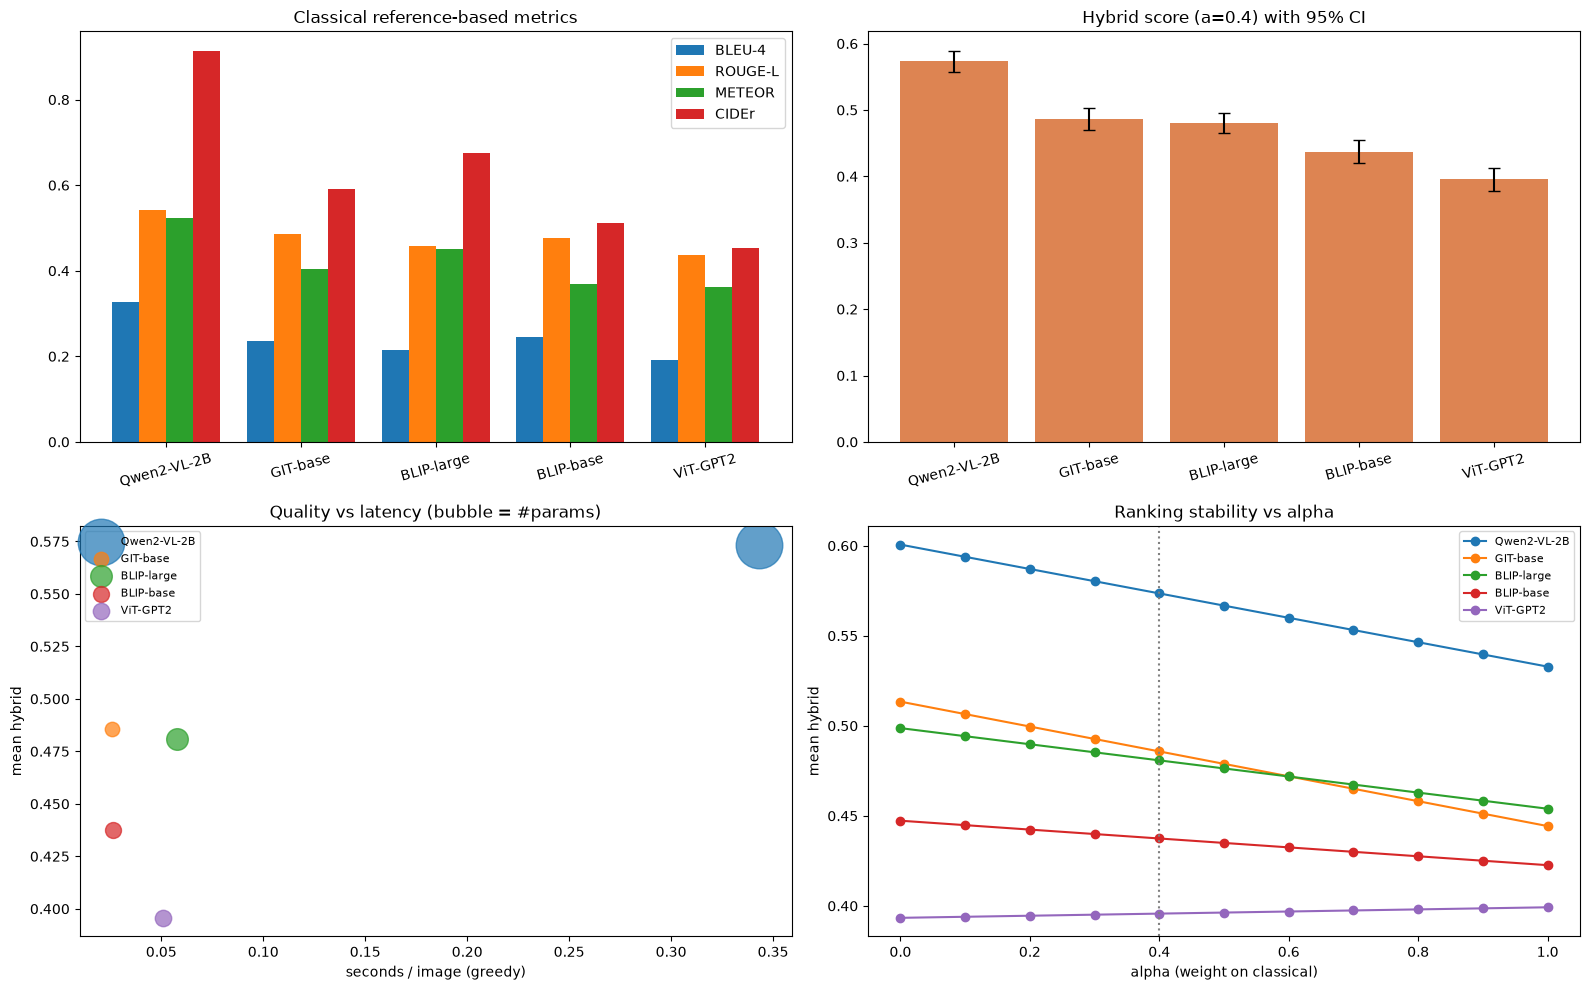


image 0 | ref: 'Two young guys with shaggy hair look at their hands while hanging out in the yard .'
   BLIP-base     : 'a man standing in the grass'
   BLIP-large    : 'they are standing in the garden looking at a cell phone'
   ViT-GPT2      : 'a woman standing next to a fence with a bat'
   GIT-base      : 'a man standing in a garden looking at a cell phone.'
   Qwen2-VL-2B   : 'Two men in a garden with one wearing a blue shirt.'

image 1 | ref: 'Several men in hard hats are operating a giant pulley system .'
   BLIP-base     : 'a metal tower'
   BLIP-large    : 'there are people on a crane that is lifting a large object'
   ViT-GPT2      : 'a crane is attached to a crane on a boat'
   GIT-base      : 'a group of people climbing a tower.'
   Qwen2-VL-2B   : 'A group of men working on a crane.'

image 2 | ref: 'A child in a pink dress is climbing up a set of stairs in an entry way .'
   BLIP-base     : 'a little girl in a pink dress'
   BLIP-large    : 'there is a little girl that i

In [12]:
# ============================================================================
# 6. Comparison table, plots, files
# ============================================================================
rows = []
for n in order:
    s, o = S[n], OUT[n]
    rows.append({
        "architecture": n, "params_M": o["params_m"], "s/img": o["sec_per_image"], "VRAM_GiB": o["peak_vram_gib"],
        "BLEU-4": round(s["summ"]["bleu4"], 3), "ROUGE-L": round(s["summ"]["rougeL"], 3), "METEOR": round(s["summ"]["meteor"], 3),
        "CIDEr": round(s["summ"]["cider"], 3),
        "CLIP-L/14 cos": ci_str(bootstrap_ci(s["rg"]), 3), "CLIP-B/32 cos": round(float(s["rg2"].mean()), 3),
        "J(pi) MC return": ci_str(bootstrap_ci(s["J"]), 3), "SCST adv": ci_str(bootstrap_ci(s["adv"]), 3),
        "% rollouts > greedy": round(100 * float((s["adv_traj"] > 0).mean()), 1),
        "reward std": round(float(s["rstd"].mean()), 3), "best-of-k reward": round(float(s["bok"].mean()), 3),
        "avg words": round(s["length"], 1), "distinct caps": round(s["distinct"], 2),
        f"Hybrid (a={CFG['alpha']})": ci_str(bootstrap_ci(s["hybrid"]), 3),
    })
res = pd.DataFrame(rows)
pd.set_option("display.width", 250, "display.max_columns", 60)
print(res.set_index("architecture").T.to_string())
if FAILED: print("\nFAILED architectures (not scored):", FAILED)

res.to_csv(f"{OUT_DIR}/comparative_results.csv", index=False)
sens.to_csv(f"{OUT_DIR}/comparative_alpha_sensitivity.csv"); sig_df.to_csv(f"{OUT_DIR}/comparative_significance.csv", index=False)
pd.concat([S[n]["per"].assign(architecture=n, id=range(N), clip_L14=S[n]["rg"], J=S[n]["J"], scst_adv=S[n]["adv"],
                              hybrid=S[n]["hybrid"], caption=OUT[n]["greedy"]) for n in names]).to_csv(f"{OUT_DIR}/comparative_per_sample.csv", index=False)
write_manifest(f"{OUT_DIR}/run_manifest.json", {**CFG, "archs": ARCH_IDS},
               extra=dict(flickr_source=FLICKR_SRC, failed=FAILED, commits={n: OUT[n]["commit"] for n in names}))

# cross-architecture meta-evaluation: does the RL reward agree with the human-reference metrics across ALL captions?
from scipy.stats import spearmanr
allr = np.concatenate([S[n]["rg"] for n in names])
meta = {m: float(spearmanr(allr, np.concatenate([S[n]["per"][m] for n in names]))[0]) for m in ("meteor", "rougeL", "cider")}
print("\nSpearman(CLIP-L/14 reward, human-reference metric) over all captions of all architectures:", {k: round(v, 3) for k, v in meta.items()})

fig, ax = plt.subplots(2, 2, figsize=(16, 10))
cols = ["BLEU-4", "ROUGE-L", "METEOR", "CIDEr"]; w = 0.8 / len(cols); x = np.arange(len(order))
for j, c in enumerate(cols): ax[0, 0].bar(x + (j - 1.5) * w, [res.set_index("architecture").loc[n, c] for n in order], w, label=c)
ax[0, 0].set_xticks(x); ax[0, 0].set_xticklabels(order, rotation=15); ax[0, 0].legend(); ax[0, 0].set_title("Classical reference-based metrics")
m = [bootstrap_ci(S[n]["hybrid"]) for n in order]
ax[0, 1].bar(order, [v[0] for v in m], yerr=[[v[0] - v[1] for v in m], [v[2] - v[0] for v in m]], capsize=4, color="#DD8452")
ax[0, 1].set_title(f"Hybrid score (a={CFG['alpha']}) with 95% CI"); ax[0, 1].tick_params(axis="x", rotation=15)
for n in order: ax[1, 0].scatter(OUT[n]["sec_per_image"], S[n]["hybrid"].mean(), s=OUT[n]["params_m"] / 2 + 20, alpha=0.7, label=n)
ax[1, 0].set_xlabel("seconds / image (greedy)"); ax[1, 0].set_ylabel("mean hybrid"); ax[1, 0].set_title("Quality vs latency (bubble = #params)"); ax[1, 0].legend(fontsize=8)
for n in order: ax[1, 1].plot(sens.index, sens[n], marker="o", label=n)
ax[1, 1].axvline(CFG["alpha"], color="gray", ls=":"); ax[1, 1].set_xlabel("alpha (weight on classical)"); ax[1, 1].set_ylabel("mean hybrid")
ax[1, 1].set_title("Ranking stability vs alpha"); ax[1, 1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/comparative_plots.png", dpi=150); plt.show()

# qualitative: same image, every architecture
for i in range(3):
    print(f"\nimage {i} | ref: {refs[i][0]!r}")
    for n in names: print(f"   {n:14s}: {OUT[n]['greedy'][i]!r}")

core = res[["architecture", "params_M", "s/img", "BLEU-4", "ROUGE-L", "METEOR", "CIDEr", "CLIP-L/14 cos", "J(pi) MC return", "SCST adv", f"Hybrid (a={CFG['alpha']})"]]
md = ("## Comparative VLM results\n\n" + df_to_md(core) + f"\n\nRanking-stability across alpha: {n_distinct} distinct ranking(s).\n\n"
      "### Paired bootstrap (hybrid)\n" + df_to_md(sig_df) + "\n" + (f"\nFailed to run: {FAILED}\n" if FAILED else ""))
open(f"{OUT_DIR}/RESULTS_comparative.md", "w").write(md); print("\n" + md)
print(f"Saved everything in ./{OUT_DIR}/")